#**Import library**

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#**Import data**


In [54]:
data = pd.read_csv("https://raw.githubusercontent.com/04thanhnt/Employee-Salary-Analysis/refs/heads/main/job_salary_prediction_dataset.csv")
data.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [55]:
data.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [56]:
missing_values = data.isnull().sum()
display(missing_values[missing_values > 0])

,0


In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [58]:
object_datatype_cols = ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']

for col in object_datatype_cols:
    print(f"Unique values for {col}:\n{data[col].unique()}\n")

Unique values for job_title:
['AI Engineer' 'Data Analyst' 'Frontend Developer' 'Business Analyst'
 'Product Manager' 'Backend Developer' 'Machine Learning Engineer'
 'DevOps Engineer' 'Software Engineer' 'Cybersecurity Analyst'
 'Data Scientist' 'Cloud Engineer']

Unique values for education_level:
['Bachelor' 'PhD' 'High School' 'Diploma' 'Master']

Unique values for industry:
['Healthcare' 'Telecom' 'Media' 'Retail' 'Manufacturing' 'Education'
 'Finance' 'Technology' 'Consulting' 'Government']

Unique values for company_size:
['Medium' 'Small' 'Large' 'Enterprise' 'Startup']

Unique values for location:
['India' 'Australia' 'Singapore' 'Canada' 'Sweden' 'USA' 'Netherlands'
 'Remote' 'Germany' 'UK']

Unique values for remote_work:
['Hybrid' 'No' 'Yes']



#**Analyze the salary**

In [59]:
salary_by_job_title = data.groupby('job_title')['salary'].agg(['mean', 'median', 'min', 'max', 'std','count']).sort_values(by='mean', ascending=False)
display(salary_by_job_title)

,mean,median,min,max,std,count
job_title,,,,,,
AI Engineer,173498.480640,171674.0,66371,333046,38093.174492,20945
Machine Learning Engineer,163022.504570,160933.0,59925,317377,36890.759788,20677
Product Manager,157594.932029,155655.5,59796,301294,35754.582620,20950
Cloud Engineer,152102.535290,150005.0,45030,292855,35120.102332,20686
DevOps Engineer,149959.266791,148021.0,54985,304968,34455.584420,20889
Cybersecurity Analyst,148697.695548,146737.0,54224,303178,34525.312743,20959
Data Scientist,147258.214409,145231.5,51349,288049,34227.020507,20890
Software Engineer,141739.521460,139432.5,51313,284442,33621.958420,20876
Backend Developer,139202.768663,136678.0,46304,290512,33198.872580,21125


# **Salary Distribution for object features**

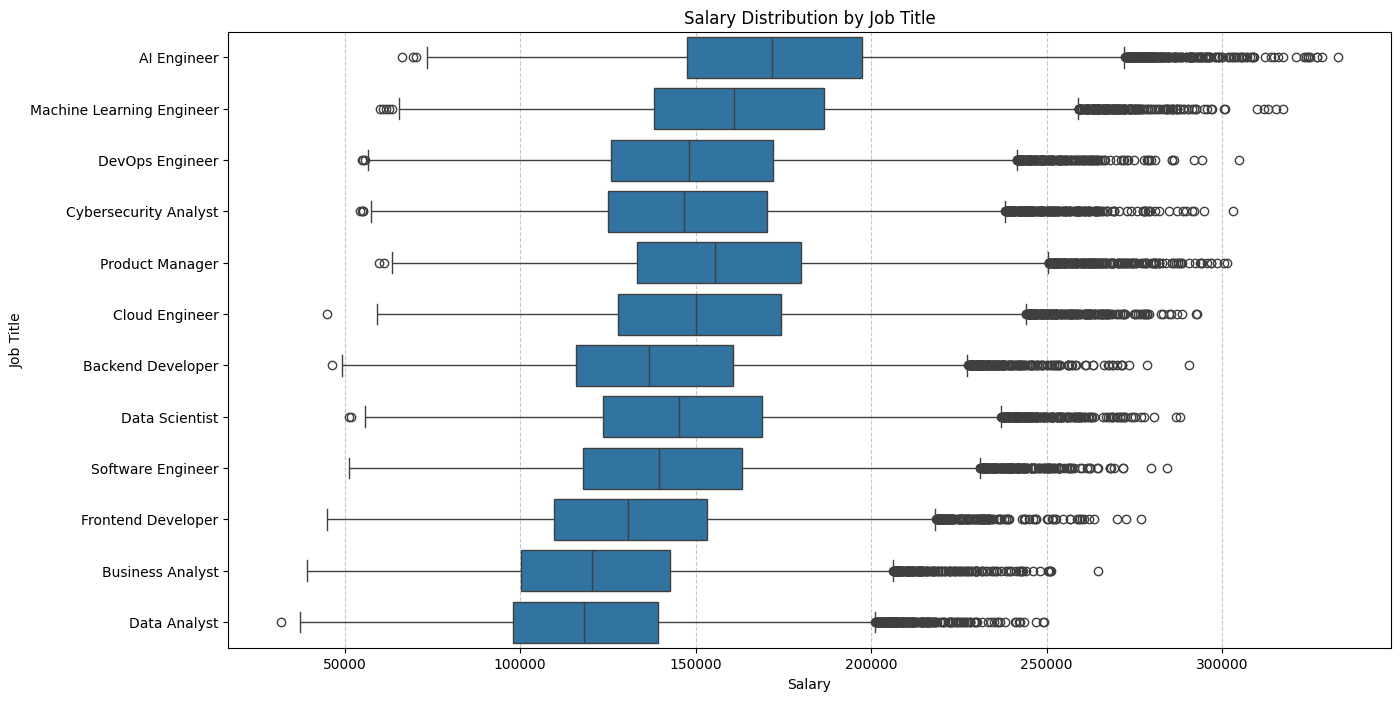

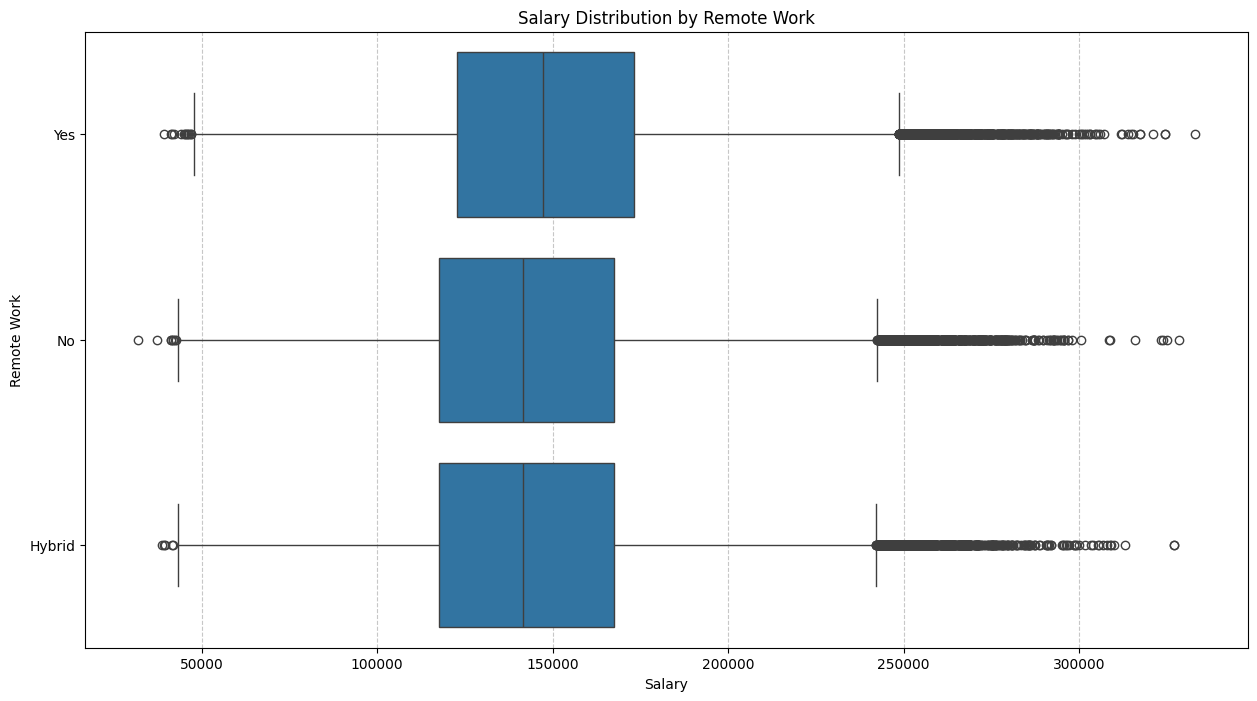

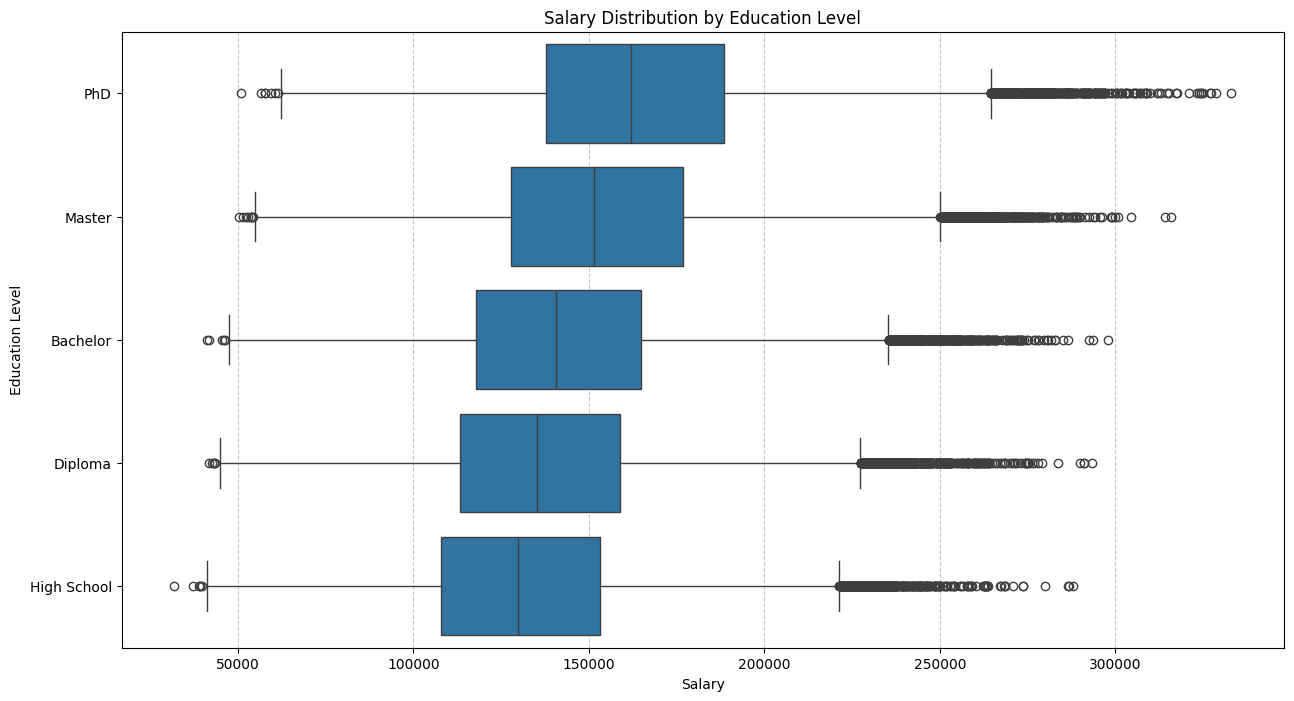

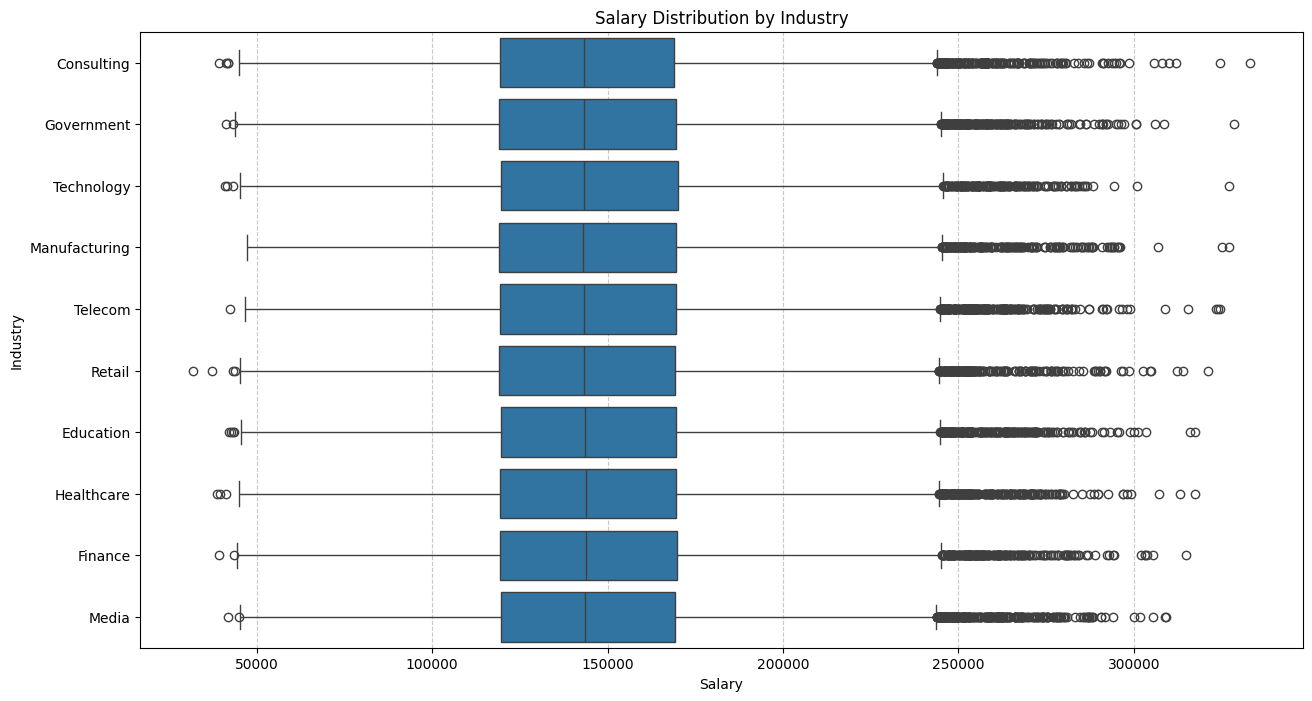

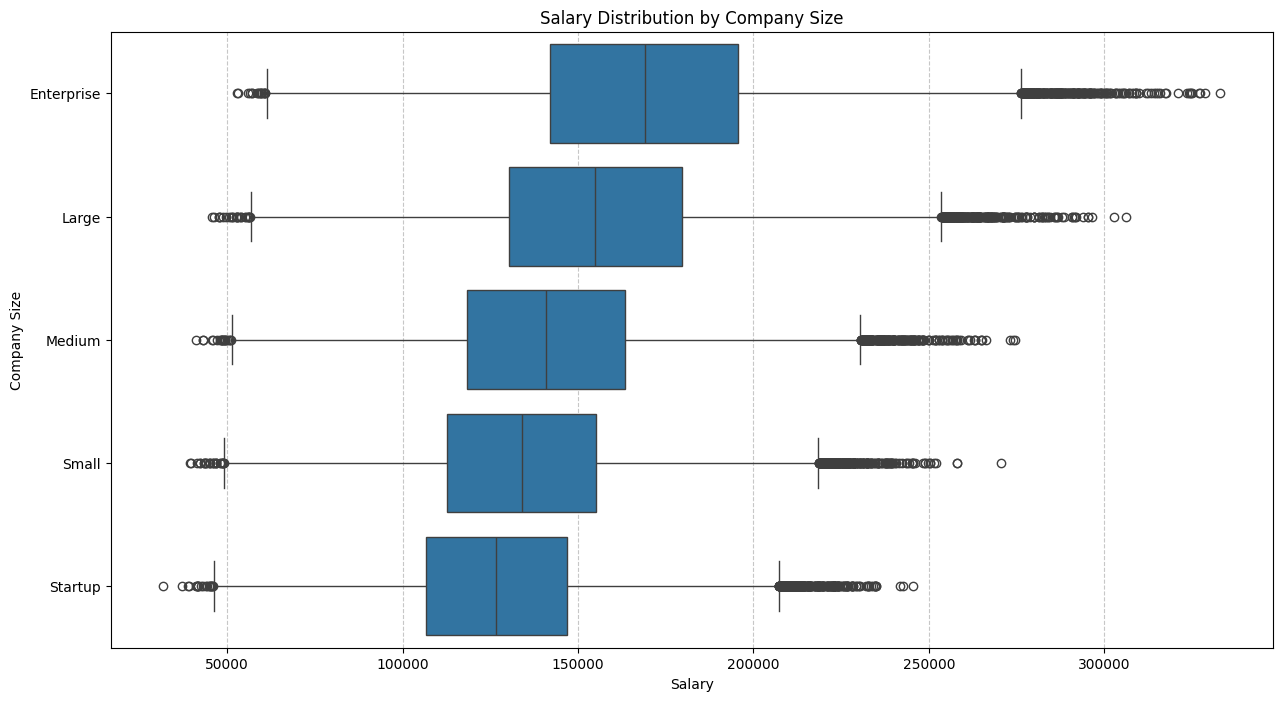

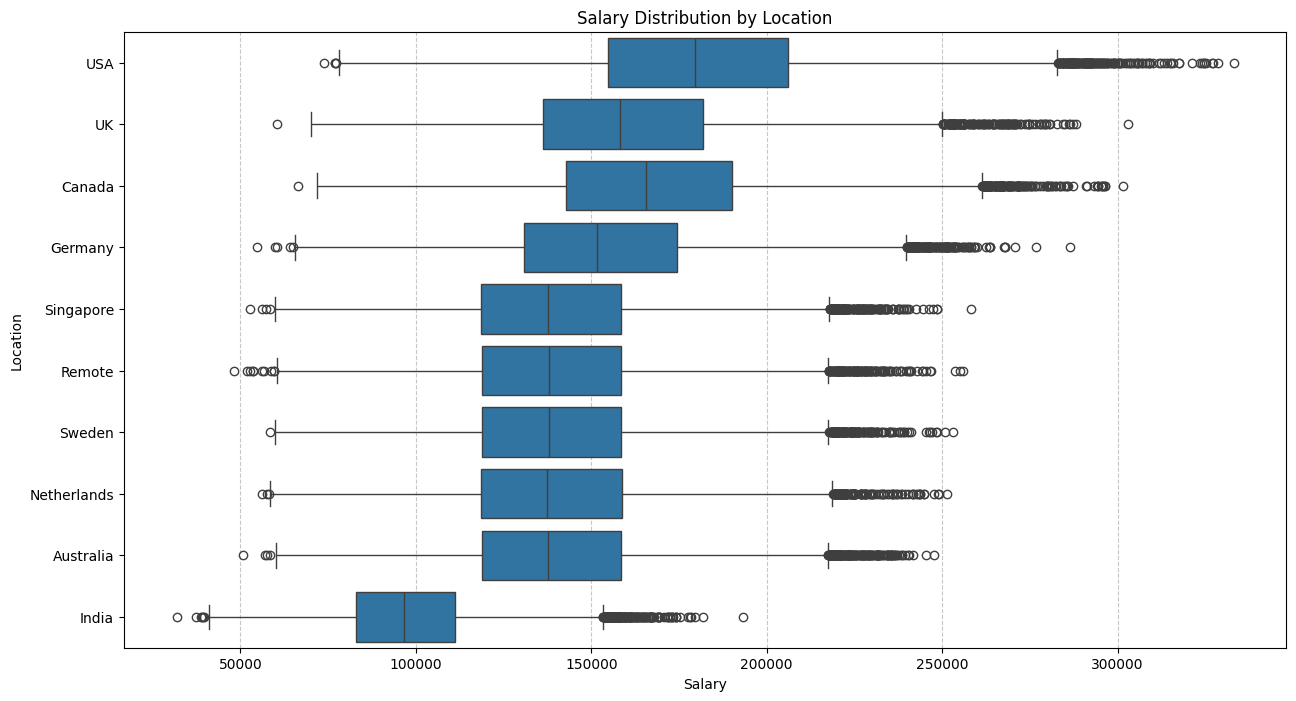

In [60]:
object_cols_for_box_plots = [
    'job_title',
    'remote_work',
    'education_level',
    'industry',
    'company_size',
    'location'
]

for col in object_cols_for_box_plots:
    plt.figure(figsize=(15, 8))
    sns.boxplot(x='salary', y=col, data=data.sort_values(by='salary', ascending=False))
    plt.title(f'Salary Distribution by {col.replace('_', ' ').title()}')
    plt.xlabel('Salary')
    plt.ylabel(col.replace('_', ' ').title())
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

**Quartile general**

25th Percentile (Low Salary Threshold): $119358.00
50th Percentile (Median Salary): $143453.00
75th Percentile (High Salary Threshold): $169492.00


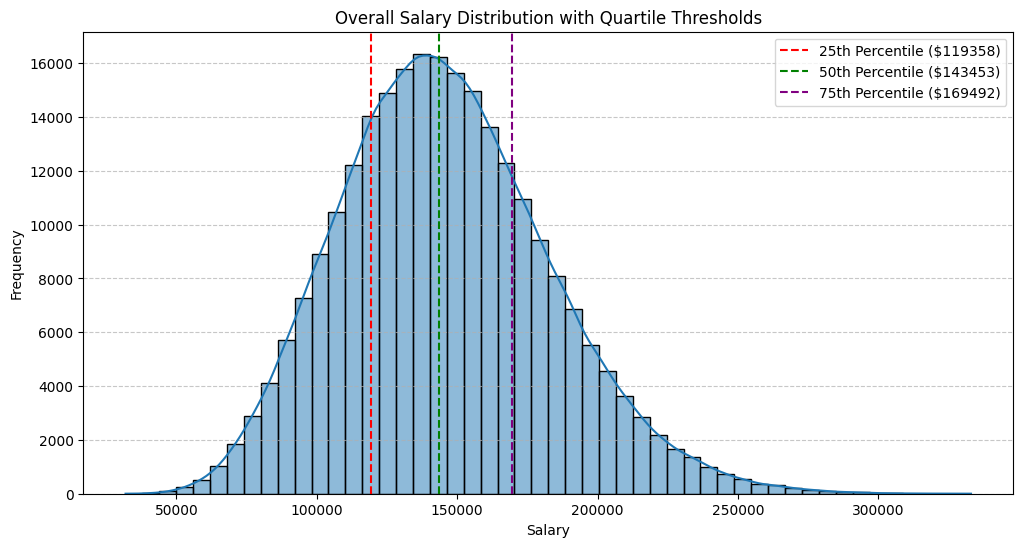

In [61]:
salary_25th_percentile = data['salary'].quantile(0.25)
salary_50th_percentile = data['salary'].quantile(0.50) # Median
salary_75th_percentile = data['salary'].quantile(0.75)

print(f"25th Percentile (Low Salary Threshold): ${salary_25th_percentile:.2f}")
print(f"50th Percentile (Median Salary): ${salary_50th_percentile:.2f}")
print(f"75th Percentile (High Salary Threshold): ${salary_75th_percentile:.2f}")

plt.figure(figsize=(12, 6))
sns.histplot(data['salary'], bins=50, kde=True)
plt.axvline(salary_25th_percentile, color='red', linestyle='--', label=f'25th Percentile (${salary_25th_percentile:.0f})')
plt.axvline(salary_50th_percentile, color='green', linestyle='--', label=f'50th Percentile (${salary_50th_percentile:.0f})')
plt.axvline(salary_75th_percentile, color='purple', linestyle='--', label=f'75th Percentile (${salary_75th_percentile:.0f})')
plt.title('Overall Salary Distribution with Quartile Thresholds')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [62]:
salary_quartiles_by_job_title = data.groupby('job_title')['salary'].quantile([0.25, 0.50, 0.75]).unstack().sort_values(by=0.5, ascending=False)
salary_quartiles_by_job_title.columns = ['25th_percentile', '50th_percentile', '75th_percentile']
display(salary_quartiles_by_job_title)

,25th_percentile,50th_percentile,75th_percentile
job_title,,,
AI Engineer,147656.00,171674.0,197491.00
Machine Learning Engineer,138044.00,160933.0,186460.00
Product Manager,133200.75,155655.5,180141.75
Cloud Engineer,127965.00,150005.0,174456.00
DevOps Engineer,125860.00,148021.0,172099.00
Cybersecurity Analyst,124981.00,146737.0,170253.50
Data Scientist,123540.75,145231.5,168962.25
Software Engineer,117949.75,139432.5,163190.00
Backend Developer,115936.00,136678.0,160549.00


In [63]:
conditions_general = [
    data['salary'] < salary_25th_percentile,
    (data['salary'] >= salary_25th_percentile) & (data['salary'] <= salary_75th_percentile),
    data['salary'] > salary_75th_percentile
]
choices_general = ['Low', 'Middle', 'High']

data['salary_category_general'] = np.select(conditions_general, choices_general, default='Unknown')

print("General Salary Category Distribution:")
display(data['salary_category_general'].value_counts())


General Salary Category Distribution:


,count
salary_category_general,
Middle,125005
Low,62498
High,62497


In [64]:
# Merge the job-specific quartiles with the main dataframe
data_merged_quartiles = pd.merge(data, salary_quartiles_by_job_title, on='job_title', how='left')

# Define conditions for job-specific salary categories
conditions_job_specific = [
    data_merged_quartiles['salary'] < data_merged_quartiles['25th_percentile'],
    (data_merged_quartiles['salary'] >= data_merged_quartiles['25th_percentile']) & (data_merged_quartiles['salary'] <= data_merged_quartiles['75th_percentile']),
    data_merged_quartiles['salary'] > data_merged_quartiles['75th_percentile']
]
choices_job_specific = ['Low', 'Middle', 'High']

data_merged_quartiles['salary_category_job_specific'] = np.select(conditions_job_specific, choices_job_specific, default='Unknown')

print("Job-Specific Salary Category Distribution:")
display(data_merged_quartiles['salary_category_job_specific'].value_counts())

# Update the original 'data' DataFrame with the new column
data['salary_category_job_specific'] = data_merged_quartiles['salary_category_job_specific']

Job-Specific Salary Category Distribution:


,count
salary_category_job_specific,
Middle,125002
Low,62499
High,62499


In [65]:
data.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_category_general,salary_category_job_specific
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,Low,Low
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,Low,Low
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,Middle,Middle
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,High,High
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,Middle,Middle


#**Mean and Median salary in each factor**

In [66]:
factors = ['job_title', 'industry' , 'location', 'remote_work','education_level', 'company_size', 'experience_years', 'skills_count' ,
           'certifications']

def categorize_salary(salary_value):
    if salary_value < salary_25th_percentile:
        return 'Low'
    elif salary_value <= salary_75th_percentile:
        return 'Middle'
    else:
        return 'High'

for factor in factors:
    # Aggregate both median and mean salaries
    salary_stats = data.groupby(factor)['salary'].agg(['median', 'mean']).sort_values(by='median', ascending=False)
    print(f"\nSalary Statistics by {factor.replace('_', ' ').title()}:")

    # Apply categorization to the median salaries
    # The categorize_salary function expects a 'salary' column, so we'll apply it to the 'median' column
    salary_stats['salary_category_general'] = salary_stats['median'].apply(categorize_salary)
    display(salary_stats)


Salary Statistics by Job Title:


,median,mean,salary_category_general
job_title,,,
AI Engineer,171674.0,173498.480640,High
Machine Learning Engineer,160933.0,163022.504570,Middle
Product Manager,155655.5,157594.932029,Middle
Cloud Engineer,150005.0,152102.535290,Middle
DevOps Engineer,148021.0,149959.266791,Middle
Cybersecurity Analyst,146737.0,148697.695548,Middle
Data Scientist,145231.5,147258.214409,Middle
Software Engineer,139432.5,141739.521460,Middle
Backend Developer,136678.0,139202.768663,Middle



Salary Statistics by Industry:


,median,mean,salary_category_general
industry,,,
Healthcare,143998.5,145759.995702,Middle
Finance,143858.0,145801.639468,Middle
Education,143627.0,145993.564547,Middle
Media,143591.5,145891.271071,Middle
Telecom,143380.0,145876.511967,Middle
Technology,143359.0,145863.808377,Middle
Retail,143234.0,145399.699408,Middle
Consulting,143202.0,145451.638293,Middle
Government,143176.0,145613.869242,Middle



Salary Statistics by Location:


...

,median,mean,salary_category_general
experience_years,,,
20,171717.0,173179.709650,High
19,168077.0,169797.362442,Middle
18,165839.5,167421.185837,Middle
17,162413.0,164282.181423,Middle
16,160629.0,162290.866980,Middle
15,157214.5,158981.141636,Middle
14,154487.0,156413.152885,Middle
13,152771.0,154082.616121,Middle
12,148915.0,150779.033238,Middle



Salary Statistics by Skills Count:


,median,mean,salary_category_general
skills_count,,,
19,150933.5,153156.047503,Middle
18,150620.5,152943.172977,Middle
17,149418.0,151683.249357,Middle
16,148767.0,150726.477560,Middle
15,148549.5,150513.034216,Middle
14,147507.0,149399.920890,Middle
13,145856.0,148243.470880,Middle
12,145436.0,147792.524791,Middle
11,144390.0,146807.626294,Middle



Salary Statistics by Certifications:


,median,mean,salary_category_general
certifications,,,
5,147291.5,149607.379081,Middle
4,145914.0,148103.275327,Middle
3,144486.5,146884.292491,Middle
2,142481.5,144868.706976,Middle
1,141277.5,143428.188796,Middle
0,139382.0,141492.411877,Middle


#**Pearson correlation for numerical variables**

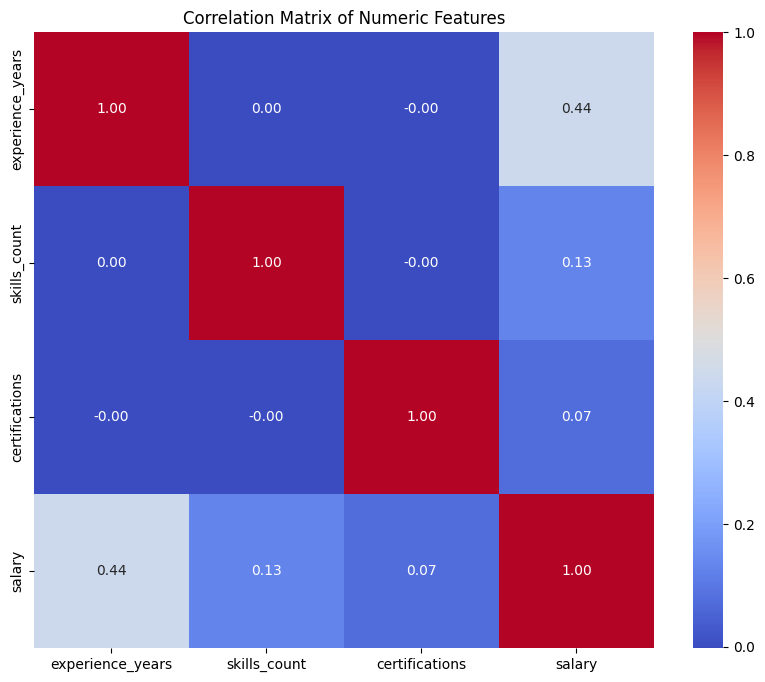

In [67]:
numeric_data = data.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [68]:
from scipy.stats import pearsonr

numerical_cols = ['experience_years', 'skills_count', 'certifications']
salary = data['salary']

print('Hypothesis Testing for Pearson Correlation with Salary')
for col in numerical_cols:
    correlation_coefficient, p_value = pearsonr(data[col], salary)
    print(f'\nPearson Correlation for {col} and Salary:')
    print(f'  Correlation Coefficient (r): {correlation_coefficient:.4f}')
    print(f'  P-value: {p_value:.4f}')

    if p_value < 0.05:
        print(f'  Conclusion: The correlation between {col} and Salary is statistically significant (p < 0.05).')
    else:
        print(f'  Conclusion: The correlation between {col} and Salary is NOT statistically significant (p >= 0.05).')

Hypothesis Testing for Pearson Correlation with Salary

Pearson Correlation for experience_years and Salary:
  Correlation Coefficient (r): 0.4376
  P-value: 0.0000
  Conclusion: The correlation between experience_years and Salary is statistically significant (p < 0.05).

Pearson Correlation for skills_count and Salary:
  Correlation Coefficient (r): 0.1273
  P-value: 0.0000
  Conclusion: The correlation between skills_count and Salary is statistically significant (p < 0.05).

Pearson Correlation for certifications and Salary:
  Correlation Coefficient (r): 0.0738
  P-value: 0.0000
  Conclusion: The correlation between certifications and Salary is statistically significant (p < 0.05).


#**Encoding Ordinal Features**


In [69]:
from sklearn.preprocessing import OrdinalEncoder
# Define the order
education_order = ['High School', 'Diploma','Bachelor','Master','PhD']
company_size_order = ['Startup','Small','Medium','Large','Enterprise']


encoder = OrdinalEncoder(categories=[education_order,company_size_order])


data[['education_level_encoded','company_size_encoded']] = encoder.fit_transform(data[['education_level', 'company_size']])

data['education_level_encoded'] = (data['education_level_encoded'].astype(int))
data['company_size_encoded'] = (data['company_size_encoded'].astype(int))

print("\nEducation Level Encoding:")
for i, level in enumerate(education_order):
    print(f"{level:<15} -> {i}")

print("\nCompany Size Encoding:")
for i, size in enumerate(company_size_order):
    print(f"{size:<15} -> {i}")

display(
    data[['education_level','education_level_encoded','company_size','company_size_encoded']].head(10))


Education Level Encoding:
High School     -> 0
Diploma         -> 1
Bachelor        -> 2
Master          -> 3
PhD             -> 4

Company Size Encoding:
Startup         -> 0
Small           -> 1
Medium          -> 2
Large           -> 3
Enterprise      -> 4


,education_level,education_level_encoded,company_size,company_size_encoded
0,Bachelor,2,Medium,2
1,Bachelor,2,Small,1
2,PhD,4,Medium,2
3,PhD,4,Medium,2
4,Bachelor,2,Large,3
5,High School,0,Enterprise,4
6,High School,0,Enterprise,4
7,Bachelor,2,Enterprise,4
8,Diploma,1,Enterprise,4
9,PhD,4,Enterprise,4


#**Spearman Correlation for Ordinal Features**


In [70]:
from scipy.stats import spearmanr

ordinal_cols = ['education_level_encoded', 'company_size_encoded']
salary = data['salary']

print('Hypothesis Testing for Pearson Correlation with Salary')
for col in ordinal_cols:
    correlation_coefficient, p_value = spearmanr(data[col], salary)
    print(f'\nSpearman Correlation for {col} and Salary:')
    print(f'  Correlation Coefficient (r): {correlation_coefficient:.4f}')
    print(f'  P-value: {p_value:.4f}')

    if p_value < 0.05:
        print(f'  Conclusion: The correlation between {col} and Salary is statistically significant (p < 0.05).')
    else:
        print(f'  Conclusion: The correlation between {col} and Salary is NOT statistically significant (p >= 0.05).')

Hypothesis Testing for Pearson Correlation with Salary

Spearman Correlation for education_level_encoded and Salary:
  Correlation Coefficient (r): 0.3002
  P-value: 0.0000
  Conclusion: The correlation between education_level_encoded and Salary is statistically significant (p < 0.05).

Spearman Correlation for company_size_encoded and Salary:
  Correlation Coefficient (r): 0.3900
  P-value: 0.0000
  Conclusion: The correlation between company_size_encoded and Salary is statistically significant (p < 0.05).


# **Levene's Test for Homogeneity of Variances**


In [71]:
from scipy.stats import levene

categorical_for_levene = ['job_title', 'industry', 'remote_work', 'location']

for col in categorical_for_levene:
    categories = data[col].unique()


    salary_groups = [data['salary'][data[col] == cat] for cat in categories]


    statistic, p_value_levene = levene(*salary_groups)

    print(f"\nLevene's Test for {col} and Salary:")
    print(f"  Statistic: {statistic:.4f}")
    print(f"  P-value: {p_value_levene:.4f}")

    if p_value_levene < 0.05:
        print(f"  Conclusion: Variances are NOT homogeneous. Consider using Welch ANOVA for {col}.")
    else:
        print(f"  Conclusion: Variances ARE homogeneous. Standard ANOVA is appropriate for {col}.")


Levene's Test for job_title and Salary:
  Statistic: 127.2229
  P-value: 0.0000
  Conclusion: Variances are NOT homogeneous. Consider using Welch ANOVA for job_title.

Levene's Test for industry and Salary:
  Statistic: 0.1868
  P-value: 0.9956
  Conclusion: Variances ARE homogeneous. Standard ANOVA is appropriate for industry.

Levene's Test for remote_work and Salary:
  Statistic: 6.0170
  P-value: 0.0024
  Conclusion: Variances are NOT homogeneous. Consider using Welch ANOVA for remote_work.

Levene's Test for location and Salary:
  Statistic: 947.5953
  P-value: 0.0000
  Conclusion: Variances are NOT homogeneous. Consider using Welch ANOVA for location.


# **Applying ANOVA and Welch ANOVA based on Levene's Test Results**

As determined by Levene's test:
*   **Standard ANOVA** will be applied to "industry" (homogeneous variances).
*   **Welch ANOVA** will be applied to "job_title", "remote_work", and "location" (non-homogeneous variances).

In [72]:
# Install pingouin for Welch ANOVA
!pip install pingouin

In [73]:
import pingouin as pg
from scipy.stats import f_oneway

# Variables identified for Welch ANOVA
welch_anova_cols = ['job_title', 'remote_work', 'location']

print("\nWelch ANOVA Results (for non-homogeneous variances)")
for col in welch_anova_cols:
    print(f"\nWelch ANOVA for {col} and Salary:")
    # Perform Welch ANOVA using pingouin
    aov = pg.welch_anova(data=data, dv='salary', between=col)
    print(aov)

    if aov['p_unc'].iloc[0] < 0.05:
        print(f"  Conclusion: There is a statistically significant difference in mean salary across different {col} categories.")
    else:
        print(f"  Conclusion: There is no statistically significant difference in mean salary across different {col} categories.")


Welch ANOVA Results (for non-homogeneous variances)

Welch ANOVA for job_title and Salary:
      Source  ddof1         ddof2            F  p_unc       np2
0  job_title     11  98467.824521  4443.129521    0.0  0.161269
  Conclusion: There is a statistically significant difference in mean salary across different job_title categories.

Welch ANOVA for remote_work and Salary:
        Source  ddof1          ddof2           F          p_unc       np2
0  remote_work      2  166641.563223  559.636677  5.827391e-243  0.004497
  Conclusion: There is a statistically significant difference in mean salary across different remote_work categories.

Welch ANOVA for location and Salary:
     Source  ddof1          ddof2             F  p_unc       np2
0  location      9  101688.809623  17898.935096    0.0  0.323531
  Conclusion: There is a statistically significant difference in mean salary across different location categories.


# **Performing Standard ANOVA with "statsmodels"**


In [74]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

standard_anova_cols = 'industry'

print(f"\nStandard ANOVA Result (for homogeneous variances) using statsmodels")
print(f"\nStandard ANOVA for {standard_anova_cols} and Salary:")

formula = f'salary ~ C({standard_anova_cols})'
model = smf.ols(formula=formula, data=data).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
display(anova_table)

p_value_standard_sm = anova_table['PR(>F)'].iloc[0]

if p_value_standard_sm < 0.05:
    print(f"  Conclusion: There is a statistically significant difference in mean salary across different {standard_anova_cols} categories .")
else:
    print(f"  Conclusion: There is no statistically significant difference in mean salary across different {standard_anova_cols} categories.")


Standard ANOVA Result (for homogeneous variances) using statsmodels

Standard ANOVA for industry and Salary:


,sum_sq,df,F,PR(>F)
C(industry),9.474734e+09,9.0,0.752303,0.660976
Residual,3.498279e+14,249990.0,NaN,NaN


  Conclusion: There is no statistically significant difference in mean salary across different industry categories.


# **Effect size for Industry**

In [75]:

ss_between = anova_table['sum_sq'].iloc[0]  # Sum of squares for the factor (C(industry))
df_between = anova_table['df'].iloc[0]      # Degrees of freedom for the factor
ss_within = anova_table['sum_sq'].iloc[1]   # Residual sum of squares
df_within = anova_table['df'].iloc[1]       # Residual degrees of freedom
ss_total = ss_between + ss_within          # Total sum of squares

# Calculate Mean Square Within (MS_within)
ms_within = ss_within / df_within

# Calculate Omega Squared (ω²)
omega_squared = (ss_between - (df_between * ms_within)) / (ss_total + ms_within)

print(f"\nEffect Size for {standard_anova_cols} and Salary")
print(f"  Omega Squared (ω²): {omega_squared:.4f}")

if anova_table['PR(>F)'].iloc[0] < 0.05:
    print(f"Interpretation: {omega_squared:.2%} of the variance in salary is explained by {standard_anova_cols}-->(Statistically significant)")
else:
    print(f"Interpretation: Although not statistically significant, {omega_squared:.2%} of the variance in salary is explained by {standard_anova_cols}.")


Effect Size for industry and Salary
  Omega Squared (ω²): -0.0000
Interpretation: Although not statistically significant, -0.00% of the variance in salary is explained by industry.


# **Multiple Linear Regression**


In [76]:
import statsmodels.formula.api as smf
formula = 'salary ~ experience_years + skills_count + certifications + C(education_level) + C(company_size) + C(job_title) + C(remote_work) + C(location) + C(industry)'

multi_reg_model = smf.ols(formula=formula, data=data).fit()

print("Multiple Linear Regression Summary")
display(multi_reg_model.summary())

Multiple Linear Regression Summary


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 salary   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                 1.566e+05
Date:                Sat, 25 Jul 2026   Prob (F-statistic):               0.00
Time:                        05:15:55   Log-Likelihood:            -2.5737e+06
No. Observations:              250000   AIC:                         5.148e+06
Df Residuals:                  249957   BIC:                         5.148e+06
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                  1.467e+05     99.261   1478.310      0.000    1.47e+05    1.47e+05
C(education_level)[T.Diploma]             -5330.8898     45.341   -117.574      0.000   -5419.757   -5242.023
C(education_level)[T.High School]         -1.071e+04     45.276   -236.597      0.000   -1.08e+04   -1.06e+04
C(education_level)[T.Master]               1.081e+04     45.214    239.051      0.000    1.07e+04    1.09e+04
C(education_level)[T.PhD]                  2.156e+04     45.324    475.623      0.000    2.15e+04    2.16e+04
C(company_size)[T.Large]                   -1.41e+04     45.251   -311.504      0.000   -1.42e+04    -1.4e+04
C(company_size)[T.Medium]                 -2.827e+04     45.302   -624.051      0.000   -2.84e+04   -2.82e+04
C(company_size)[T.Small]                  -3.538e+04     45.255   -781.825      0.000   -3.55e+04   -3.53e+04
C(company_size)[T.Startup]                -4.237e+04     45.396   -933.291      0.000   -4.25e+04   -4.23e+04
C(job_title)[T.Backend Developer]         -3.441e+04     69.810   -492.900      0.000   -3.45e+04   -3.43e+04
C(job_title)[T.Business Analyst]          -5.157e+04     70.209   -734.520      0.000   -5.17e+04   -5.14e+04
C(job_title)[T.Cloud Engineer]            -2.153e+04     70.177   -306.732      0.000   -2.17e+04   -2.14e+04
C(job_title)[T.Cybersecurity Analyst]     -2.471e+04     69.946   -353.210      0.000   -2.48e+04   -2.46e+04
C(job_title)[T.Data Analyst]              -5.379e+04     70.147   -766.776      0.000   -5.39e+04   -5.36e+04
C(job_title)[T.Data Scientist]            -2.693e+04     70.005   -384.654      0.000   -2.71e+04   -2.68e+04
C(job_title)[T.DevOps Engineer]           -2.377e+04     70.005   -339.551      0.000   -2.39e+04   -2.36e+04
C(job_title)[T.Frontend Developer]        -4.091e+04     70.222   -582.640      0.000   -4.11e+04   -4.08e+04
C(job_title)[T.Machine Learning Engineer] -1.073e+04     70.185   -152.851      0.000   -1.09e+04   -1.06e+04
C(job_title)[T.Product Manager]           -1.617e+04     69.955   -231.095      0.000   -1.63e+04    -1.6e+04
C(job_title)[T.Software Engineer]         -3.229e+04     70.016   -461.226      0.000   -3.24e+04   -3.22e+04
C(remote_work)[T.No]                         36.2254     35.029      1.034      0.301     -32.431     104.882
C(remote_work)[T.Yes]                      5354.2810     35.103    152.530      0.000    5285.480    5423.082
C(location)[T.Canada]                      2.795e+04     63.765    438.289      0.000    2.78e+04    2.81e+04
C(location)[T.Germany]                     1.403e+04     64.023    219.143      0.000    1.39e+04    1.42e+04
C(location)[T.India]                      -4.183e+04     63.938   -654.283      0.000    -4.2e+04   -4.17e+04
C(l

In [77]:
# Extract relevant statistics from the model summary
results_df = pd.DataFrame({
    'coef': multi_reg_model.params,
    'std err': multi_reg_model.bse,
    't': multi_reg_model.tvalues,
    'P>t': multi_reg_model.pvalues
})

# Filter for cases where p_value < 0.05
significant_results = results_df[results_df['P>t'] < 0.05]

print("--- Significant Multiple Linear Regression Results (p-value < 0.05) ---")
display(significant_results.sort_values(by='P>t', ascending=True))

--- Significant Multiple Linear Regression Results (p-value < 0.05) ---


,coef,std err,t,P>t
Intercept,146739.297218,99.261495,1478.310365,0.0
C(education_level)[T.Diploma],-5330.889845,45.340910,-117.573508,0.0
C(education_level)[T.High School],-10712.143786,45.275905,-236.597010,0.0
C(education_level)[T.Master],10808.343877,45.213557,239.050951,0.0
C(education_level)[T.PhD],21556.889935,45.323515,475.622639,0.0
C(company_size)[T.Large],-14095.834397,45.250955,-311.503575,0.0
C(company_size)[T.Medium],-28270.787663,45.302021,-624.051357,0.0
C(company_size)[T.Small],-35381.225245,45.254660,-781.825018,0.0
C(company_size)[T.Startup],-42367.764939,45.396114,-933.290576,0.0
C(job_title)[T.Backend Developer],-34409.353303,69.809941,-492.900482,0.0


# **Checking Multicollinearity using VIF**


In [78]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
data_vif = data.copy()

from patsy import dmatrices

y, X = dmatrices(formula, data=data_vif, return_type='dataframe')

vif_data = pd.DataFrame()
vif_data["variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_data.sort_values(by="VIF", ascending=False))

,variable,VIF
0,Intercept,48.063933
9,C(job_title)[T.Backend Developer],1.839108
12,C(job_title)[T.Cybersecurity Analyst],1.833099
18,C(job_title)[T.Product Manager],1.832838
14,C(job_title)[T.Data Scientist],1.830704
15,C(job_title)[T.DevOps Engineer],1.830650
19,C(job_title)[T.Software Engineer],1.830156
13,C(job_title)[T.Data Analyst],1.824676
11,C(job_title)[T.Cloud Engineer],1.823348
17,C(job_title)[T.Machine Learning Engineer],1.823087
